In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
%matplotlib inline
pd.set_option('display.max_columns', None)

# if torch.cuda.is_available():
#     device = torch.device("cuda")
#     print(f"Using GPU: {torch.cuda.get_device_name(0)}")
# else:
#     device = torch.device("cpu")
#     print("Using CPU")

In [ ]:
train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')
orthogonal_df = pd.read_csv('../data/raw/orthogonal.csv')

In [5]:
train_df.columns = list(map(lambda x: x.replace(" ", "_").lower(), train_df.columns))
test_df.columns = list(map(lambda x: x.replace(" ", "_").lower(), test_df.columns))
orthogonal_df.columns = list(map(lambda x: x.replace(" ", "_").lower(), orthogonal_df.columns))

# EDA

## Check shape

In [6]:
print(f"{train_df.shape = }")
print(f"{test_df.shape = }")
print(f"{orthogonal_df.shape = }")

train_df.shape = (77002, 77)
test_df.shape = (8666, 91)
orthogonal_df.shape = (13383, 91)


In [7]:
train_df.columns

Index(['chr', 'start', 'end', 'ref', 'alt', 'class', 'gene',
       'phastconselements100way', 'phylop100way_vertebrate',
       'phylop20way_mammalian', 'phastcons100way_vertebrate',
       'phastcons20way_mammalian', 'siphy_29way_logodds',
       'phylop30way_mammalian', 'phastcons30way_mammalian', 'af', 'af_raw',
       'af_male', 'af_female', 'af_afr', 'af_ami', 'af_amr', 'af_asj',
       'af_eas', 'af_fin', 'af_nfe', 'af_oth', 'gdi', 'gdi_phred', 'rvis1',
       'rvis2', 'lof_score', 'molecular_weight', 'equipotential_point',
       'hydrophilic', 'hydrophobic', 'amphipathic_', 'cyclic', 'essential',
       'aromatic', 'aliphatic', 'nonpolar', 'polar_uncharged', 'acidic',
       'basic', 'sulfur', 'pka_cooh', 'pka_nh3', 'blosum100', 'ds_ag', 'ds_al',
       'ds_dg', 'ds_dl', 'dp_ag', 'dp_al', 'dp_dg', 'dp_dl', 'gm12878',
       'h1hesc', 'hepg2', 'hmec', 'hsmm', 'huvec', 'k562', 'nhek', 'nhlf',
       'func_frameshift', 'func_nonframeshift', 'func_nonsynonymous_snv',
       'func_

In [8]:
test_df.columns

Index(['chr', 'start', 'end', 'ref', 'alt', 'class', 'gene', 'clinpred_score',
       'revel_score', 'varity_r', 'metasvm_score', 'metalr_score',
       'vest4_score', 'm-cap_score', 'mutpred_score', 'primateai_score',
       'mutationassessor_score', 'list-s2_score', 'sift4g_score',
       'dann_rankscore', 'mutationtaster_score', 'phastconselements100way',
       'phylop100way_vertebrate', 'phylop20way_mammalian',
       'phastcons100way_vertebrate', 'phastcons20way_mammalian',
       'siphy_29way_logodds', 'phylop30way_mammalian',
       'phastcons30way_mammalian', 'af', 'af_raw', 'af_male', 'af_female',
       'af_afr', 'af_ami', 'af_amr', 'af_asj', 'af_eas', 'af_fin', 'af_nfe',
       'af_oth', 'gdi', 'gdi_phred', 'rvis1', 'rvis2', 'lof_score',
       'molecular_weight', 'equipotential_point', 'hydrophilic', 'hydrophobic',
       'amphipathic_', 'cyclic', 'essential', 'aromatic', 'aliphatic',
       'nonpolar', 'polar_uncharged', 'acidic', 'basic', 'sulfur', 'pka_cooh',
       'pk

In [9]:
deleted_cols = [col for col in test_df.columns if col not in train_df.columns]
print(f"{deleted_cols = }")

deleted_cols = ['clinpred_score', 'revel_score', 'varity_r', 'metasvm_score', 'metalr_score', 'vest4_score', 'm-cap_score', 'mutpred_score', 'primateai_score', 'mutationassessor_score', 'list-s2_score', 'sift4g_score', 'dann_rankscore', 'mutationtaster_score']


### Filter out missing columns from test and orthogonal set

In [10]:
test_df_filtered = test_df.drop(columns=deleted_cols)
orthogonal_df_filtered = orthogonal_df.drop(columns=deleted_cols)

In [11]:
print(f"{train_df.shape = }")
print(f"{test_df_filtered.shape = }")
print(f"{orthogonal_df_filtered.shape = }")

train_df.shape = (77002, 77)
test_df_filtered.shape = (8666, 77)
orthogonal_df_filtered.shape = (13383, 77)


In [12]:
(train_df.columns == test_df_filtered.columns).sum() == len(train_df.columns)

True

In [13]:
(train_df.columns == orthogonal_df_filtered.columns).sum() == len(train_df.columns)

True

## Check class label

In [14]:
train_df['class'].value_counts()

class
 1    39999
-1    37003
Name: count, dtype: int64

In [15]:
test_df_filtered['class'].value_counts()

class
 1    4356
-1    4310
Name: count, dtype: int64

In [16]:
orthogonal_df_filtered['class'].value_counts()

class
-1    12075
 1     1308
Name: count, dtype: int64

### Handle -1 in class label

In [17]:
train_df['class'] = train_df['class'].replace(-1, 0)
test_df_filtered['class'] = test_df_filtered['class'].replace(-1, 0)
orthogonal_df_filtered['class'] = orthogonal_df_filtered['class'].replace(-1, 0)


In [18]:
train_df['class'].value_counts()

class
1    39999
0    37003
Name: count, dtype: int64

In [19]:
test_df_filtered['class'].value_counts()

class
1    4356
0    4310
Name: count, dtype: int64

In [20]:
orthogonal_df_filtered['class'].value_counts()

class
0    12075
1     1308
Name: count, dtype: int64

## Check for missing data

In [21]:
for col in train_df.columns:
    missing = train_df[col].isnull().sum()/ train_df.shape[0]
    if missing > 0:
        print(f"{col}: {missing:.2%} missing values")

## Check dtype

In [22]:
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

discrete_num_cols = [col for col in num_cols if (train_df[col].nunique() < 20 and train_df[col].nunique() > 2)]
boolean_cols = [col for col in num_cols if train_df[col].nunique() == 2]
continuous_num_cols = [col for col in num_cols if col not in discrete_num_cols and col not in boolean_cols]

In [23]:
print(f"{cat_cols = }")
print(f"{num_cols = }")
print(f"{discrete_num_cols = }")
print(f"{boolean_cols = }")
print(f"{continuous_num_cols = }")

cat_cols = ['chr', 'ref', 'alt', 'gene']
num_cols = ['start', 'end', 'class', 'phastconselements100way', 'phylop100way_vertebrate', 'phylop20way_mammalian', 'phastcons100way_vertebrate', 'phastcons20way_mammalian', 'siphy_29way_logodds', 'phylop30way_mammalian', 'phastcons30way_mammalian', 'af', 'af_raw', 'af_male', 'af_female', 'af_afr', 'af_ami', 'af_amr', 'af_asj', 'af_eas', 'af_fin', 'af_nfe', 'af_oth', 'gdi', 'gdi_phred', 'rvis1', 'rvis2', 'lof_score', 'molecular_weight', 'equipotential_point', 'hydrophilic', 'hydrophobic', 'amphipathic_', 'cyclic', 'essential', 'aromatic', 'aliphatic', 'nonpolar', 'polar_uncharged', 'acidic', 'basic', 'sulfur', 'pka_cooh', 'pka_nh3', 'blosum100', 'ds_ag', 'ds_al', 'ds_dg', 'ds_dl', 'dp_ag', 'dp_al', 'dp_dg', 'dp_dl', 'gm12878', 'h1hesc', 'hepg2', 'hmec', 'hsmm', 'huvec', 'k562', 'nhek', 'nhlf', 'func_frameshift', 'func_nonframeshift', 'func_nonsynonymous_snv', 'func_startloss', 'func_stopgain', 'func_stoploss', 'omim_autosomal_dominant', 'omim_au

### Handle boolean cols

In [24]:
for col in boolean_cols:
    print(f"{col}: {train_df[col].value_counts()}")

class: class
1    39999
0    37003
Name: count, dtype: int64
func_frameshift: func_frameshift
0    75923
1     1079
Name: count, dtype: int64
func_nonframeshift: func_nonframeshift
0    76727
1      275
Name: count, dtype: int64
func_nonsynonymous_snv: func_nonsynonymous_snv
1    50788
0    26214
Name: count, dtype: int64
func_startloss: func_startloss
0    76432
1      570
Name: count, dtype: int64
func_stopgain: func_stopgain
0    52783
1    24219
Name: count, dtype: int64
func_stoploss: func_stoploss
0    76931
1       71
Name: count, dtype: int64
omim_autosomal_dominant: omim_autosomal_dominant
0    55593
1    21409
Name: count, dtype: int64
omim_autosomal_recessive: omim_autosomal_recessive
0    44945
1    32057
Name: count, dtype: int64
omim_x_linked_dominant: omim_x_linked_dominant
0    75838
1     1164
Name: count, dtype: int64
omim_x_linked_recessive: omim_x_linked_recessive
0    74636
1     2366
Name: count, dtype: int64
omim_other: omim_other
0    56996
1    20006
Name: coun

In [25]:
for col in cat_cols:
    print(f"{col}: {train_df[col].nunique()} unique values")

chr: 24 unique values
ref: 731 unique values
alt: 520 unique values
gene: 7527 unique values


In [26]:
train_df[cat_cols]

,chr,ref,alt,gene
0,chr1,G,A,SAMD11
1,chr1,G,A,SAMD11
2,chr1,G,A,SAMD11
3,chr1,C,T,SAMD11
4,chr1,G,A,SAMD11
...,...,...,...,...
76997,chrY,C,T,AMELY
76998,chrY,G,A,USP9Y
76999,chrY,G,T,NLGN4Y
77000,chrY,A,G,KDM5D


In [ ]:
gene2vec = pd.read_csv("../data/gene_embeddings/gene2vec_dim_200_iter_9_w2v.tsv", sep="\t", header=None, skiprows=1)
gene2vec = gene2vec.iloc[:, :-1]

In [28]:
gene2vec.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200
0,PLAC4,-0.032111,0.005355,-0.001208,0.392700,0.027191,0.057858,-0.065911,0.256802,0.043661,0.081228,0.023202,0.222013,0.071557,0.298946,-0.013339,-0.114272,0.154003,-0.081017,-0.137468,0.014593,-0.089869,-0.145082,0.125541,0.121973,-0.178735,-0.186689,-0.104578,0.074477,0.044344,-0.057636,0.129777,0.002043,-0.195980,-0.248932,-0.193179,-0.307444,-0.040162,0.024618,-0.329320,0.350043,-0.351233,-0.342489,0.197475,0.097474,0.177252,-0.063227,-0.094272,0.134066,-0.034647,-0.322646,0.176540,0.399930,-0.136921,0.089524,-0.265505,0.056155,-0.114520,-0.043921,0.136460,0.110123,-0.126074,-0.386099,-0.216192,-0.467993,-0.026571,-0.316578,-0.071764,-0.073386,-0.109025,-0.032311,-0.076798,0.129071,-0.398230,0.103845,-0.127273,0.153460,0.253691,-0.075152,0.082128,0.227118,-0.059686,-0.012427,-0.349187,0.184360,-0.020158,-0.275019,0.353428,0.540589,-0.100455,0.103797,-0.053086,0.040589,0.182832,0.074749,0.108041,0.093162,-0.080788,0.213834,-0.059163,-0.018710,0.123036,0.144018,-0.145407,-0.096091,0.072708,0.046129,0.316817,-0.090928,-0.350689,0.154938,0.078710,0.262781,-0.192912,0.121154,0.583622,0.038565,-0.072273,-0.148490,0.083961,0.001064,-0.010309,-0.086838,-0.104245,0.399583,0.034556,-0.266767,0.139569,-0.137786,0.049655,0.243709,-0.259705,0.005746,0.116176,-0.064795,0.021737,-0.150208,-0.544181,0.144902,-0.123439,-0.145138,0.007023,0.282544,0.067122,0.218933,0.006811,-0.322540,0.075362,-0.011021,-0.114454,0.004641,0.027711,0.223295,-0.176684,-0.206873,0.322645,-0.138353,-0.108579,-0.012369,-0.231706,-0.190557,-0.222569,0.132782,0.255285,-0.056616,-0.117585,-0.086639,0.164178,-0.173294,0.115527,0.090047,0.026410,-0.211462,0.139360,-0.286369,0.034330,0.295113,-0.110947,-0.074761,-0.012519,-0.206118,0.095494,-0.157223,-0.013321,-0.051177,-0.146006,0.070274,0.417605,-0.075699,0.114484,-0.058115,0.179668,0.199858,-0.044920,0.095846,0.041332,-0.147439,0.239312,-0.183174,-0.264830,0.104818
1,RPS2P45,-0.433589,0.383065,0.154259,-0.044726,0.406748,0.089424,0.186105,-0.038986,0.245488,-0.712083,0.371403,0.103335,-0.214362,0.289852,-0.075124,0.089711,0.066991,-0.316381,-0.072955,-0.046262,0.294902,-0.357534,-0.101237,0.060851,0.571324,0.324109,0.120020,0.333941,-0.011010,0.272334,-0.185237,-0.318986,-0.046739,-0.239863,-0.013663,-0.112714,-0.181999,0.163694,0.418043,-0.300145,-0.647533,0.150911,-0.087658,-0.274992,-0.182552,-0.044911,0.061550,0.017359,0.226339,0.027227,-0.259355,0.494472,0.105167,-0.120897,0.275746,-0.143004,-0.283966,-0.179974,-0.027514,-0.159091,-0.036365,-0.052208,-0.481170,-0.316286,0.257435,0.216632,-0.235539,-0.031878,-0.253981,0.423667,0.334069,-0.150397,-0.066526,0.046277,-0.063843,0.084919,0.510788,-0.011612,-0.234368,0.275420,-0.066170,-0.488003,-0.293517,-0.198186,-0.538148,-0.490867,-0.108545,-0.137570,-0.226896,0.322323,0.132208,-0.011927,-0.466816,0.097956,0.165386,-0.211845,0.629750,-0.225748,0.022206,0.376313,0.490305,-0.270543,-0.026564,0.229076,0.065200,0.097411,-0.429362,-0.377856,0.006021,0.170930,0.566267,-0.017705,0.127218,-0.284164,-0.096494,0.112769,0.027464,-0.322140,-0.027794,0.289901,-0.106839,-0.050302,0.154232,0.124469,-0.634441,-0.315494,0.230063,0.242073,-0.238522,0.027301,-0.114770,-0.430173,0.143546,0.110925,-0.112125,-0.336032,-0.185231,0.066420,0.746893,-0.258671,-0.062669,0.246160,-0.028002,0.088655,0.083778,-

## Feature Selection

In [29]:
X = train_df.drop(columns=['class'])
X.drop(columns=cat_cols, inplace=True)
y = train_df['class']

In [30]:
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)]

# X = X.drop(columns=to_drop)
print(f"Can be dropped due to high correlation: {to_drop}")

Can be dropped due to high correlation: ['end', 'af_raw', 'af_male', 'af_female', 'af_ami', 'af_amr', 'af_asj', 'af_fin', 'af_nfe', 'af_oth']


In [31]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)

# Get the retained column names
retained_cols = X.columns[selector.get_support(indices=True)]
# X = pd.DataFrame(X_var, columns=retained_cols)
deleted_cols = [col for col in X.columns if col not in retained_cols]
print(f"Can be dropped after low-variance filter: {deleted_cols}")

Can be dropped after low-variance filter: ['ds_ag', 'ds_al', 'ds_dg', 'ds_dl', 'func_nonframeshift', 'func_startloss', 'func_stoploss']


In [32]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

model = lgb.LGBMClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Plot top features
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = feature_importance.sort_values(ascending=False)

[LightGBM] [Info] Number of positive: 31999, number of negative: 29602
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006667 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12073
[LightGBM] [Info] Number of data points in the train set: 61601, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.519456 -> initscore=0.077863
[LightGBM] [Info] Start training from score 0.077863


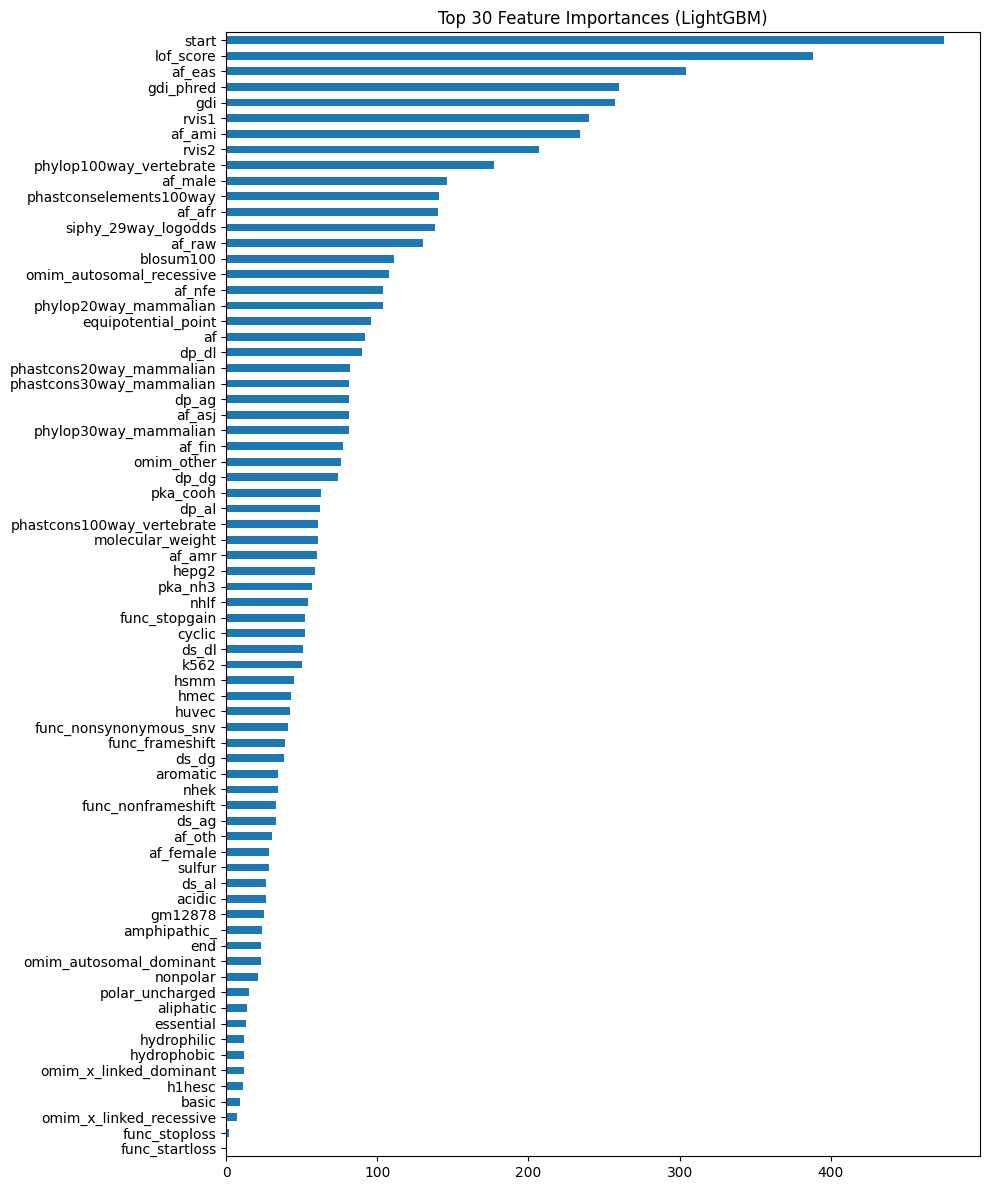

In [33]:
plt.figure(figsize=(10, 12))
top_features.plot(kind='barh')
plt.title("Top 30 Feature Importances (LightGBM)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [34]:
gene2vec.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200
0,PLAC4,-0.032111,0.005355,-0.001208,0.392700,0.027191,0.057858,-0.065911,0.256802,0.043661,0.081228,0.023202,0.222013,0.071557,0.298946,-0.013339,-0.114272,0.154003,-0.081017,-0.137468,0.014593,-0.089869,-0.145082,0.125541,0.121973,-0.178735,-0.186689,-0.104578,0.074477,0.044344,-0.057636,0.129777,0.002043,-0.195980,-0.248932,-0.193179,-0.307444,-0.040162,0.024618,-0.329320,0.350043,-0.351233,-0.342489,0.197475,0.097474,0.177252,-0.063227,-0.094272,0.134066,-0.034647,-0.322646,0.176540,0.399930,-0.136921,0.089524,-0.265505,0.056155,-0.114520,-0.043921,0.136460,0.110123,-0.126074,-0.386099,-0.216192,-0.467993,-0.026571,-0.316578,-0.071764,-0.073386,-0.109025,-0.032311,-0.076798,0.129071,-0.398230,0.103845,-0.127273,0.153460,0.253691,-0.075152,0.082128,0.227118,-0.059686,-0.012427,-0.349187,0.184360,-0.020158,-0.275019,0.353428,0.540589,-0.100455,0.103797,-0.053086,0.040589,0.182832,0.074749,0.108041,0.093162,-0.080788,0.213834,-0.059163,-0.018710,0.123036,0.144018,-0.145407,-0.096091,0.072708,0.046129,0.316817,-0.090928,-0.350689,0.154938,0.078710,0.262781,-0.192912,0.121154,0.583622,0.038565,-0.072273,-0.148490,0.083961,0.001064,-0.010309,-0.086838,-0.104245,0.399583,0.034556,-0.266767,0.139569,-0.137786,0.049655,0.243709,-0.259705,0.005746,0.116176,-0.064795,0.021737,-0.150208,-0.544181,0.144902,-0.123439,-0.145138,0.007023,0.282544,0.067122,0.218933,0.006811,-0.322540,0.075362,-0.011021,-0.114454,0.004641,0.027711,0.223295,-0.176684,-0.206873,0.322645,-0.138353,-0.108579,-0.012369,-0.231706,-0.190557,-0.222569,0.132782,0.255285,-0.056616,-0.117585,-0.086639,0.164178,-0.173294,0.115527,0.090047,0.026410,-0.211462,0.139360,-0.286369,0.034330,0.295113,-0.110947,-0.074761,-0.012519,-0.206118,0.095494,-0.157223,-0.013321,-0.051177,-0.146006,0.070274,0.417605,-0.075699,0.114484,-0.058115,0.179668,0.199858,-0.044920,0.095846,0.041332,-0.147439,0.239312,-0.183174,-0.264830,0.104818
1,RPS2P45,-0.433589,0.383065,0.154259,-0.044726,0.406748,0.089424,0.186105,-0.038986,0.245488,-0.712083,0.371403,0.103335,-0.214362,0.289852,-0.075124,0.089711,0.066991,-0.316381,-0.072955,-0.046262,0.294902,-0.357534,-0.101237,0.060851,0.571324,0.324109,0.120020,0.333941,-0.011010,0.272334,-0.185237,-0.318986,-0.046739,-0.239863,-0.013663,-0.112714,-0.181999,0.163694,0.418043,-0.300145,-0.647533,0.150911,-0.087658,-0.274992,-0.182552,-0.044911,0.061550,0.017359,0.226339,0.027227,-0.259355,0.494472,0.105167,-0.120897,0.275746,-0.143004,-0.283966,-0.179974,-0.027514,-0.159091,-0.036365,-0.052208,-0.481170,-0.316286,0.257435,0.216632,-0.235539,-0.031878,-0.253981,0.423667,0.334069,-0.150397,-0.066526,0.046277,-0.063843,0.084919,0.510788,-0.011612,-0.234368,0.275420,-0.066170,-0.488003,-0.293517,-0.198186,-0.538148,-0.490867,-0.108545,-0.137570,-0.226896,0.322323,0.132208,-0.011927,-0.466816,0.097956,0.165386,-0.211845,0.629750,-0.225748,0.022206,0.376313,0.490305,-0.270543,-0.026564,0.229076,0.065200,0.097411,-0.429362,-0.377856,0.006021,0.170930,0.566267,-0.017705,0.127218,-0.284164,-0.096494,0.112769,0.027464,-0.322140,-0.027794,0.289901,-0.106839,-0.050302,0.154232,0.124469,-0.634441,-0.315494,0.230063,0.242073,-0.238522,0.027301,-0.114770,-0.430173,0.143546,0.110925,-0.112125,-0.336032,-0.185231,0.066420,0.746893,-0.258671,-0.062669,0.246160,-0.028002,0.088655,0.083778,-

In [35]:
embedding_cols = [f'gene_vec_{i}' for i in range(gene2vec.shape[1] - 1)]
gene2vec.columns = ['gene'] + embedding_cols

df_merged = train_df.merge(gene2vec, on='gene', how='left')

In [36]:
missing_genes = df_merged['gene_vec_0'].isnull().sum()
print(f"✅ Merged gene embeddings. {missing_genes} rows have missing gene embeddings.")

✅ Merged gene embeddings. 3074 rows have missing gene embeddings.


In [37]:
df_merged[df_merged['gene_vec_0'].isnull()].head()

,chr,start,end,ref,alt,class,gene,phastconselements100way,phylop100way_vertebrate,phylop20way_mammalian,phastcons100way_vertebrate,phastcons20way_mammalian,siphy_29way_logodds,phylop30way_mammalian,phastcons30way_mammalian,af,af_raw,af_male,af_female,af_afr,af_ami,af_amr,af_asj,af_eas,af_fin,af_nfe,af_oth,gdi,gdi_phred,rvis1,rvis2,lof_score,molecular_weight,equipotential_point,hydrophilic,hydrophobic,amphipathic_,cyclic,essential,aromatic,aliphatic,nonpolar,polar_uncharged,acidic,basic,sulfur,pka_cooh,pka_nh3,blosum100,ds_ag,ds_al,ds_dg,ds_dl,dp_ag,dp_al,dp_dg,dp_dl,gm12878,h1hesc,hepg2,hmec,hsmm,huvec,k562,nhek,nhlf,func_frameshift,func_nonframeshift,func_nonsynonymous_snv,func_startloss,func_stopgain,func_stoploss,omim_autosomal_dominant,omim_autosomal_recessive,omim_x_linked_dominant,omim_x_linked_recessive,omim_other,gene_vec_0,gene_vec_1,gene_vec_2,gene_vec_3,gene_vec_4,gene_vec_5,gene_vec_6,gene_vec_7,gene_vec_8,gene_vec_9,gene_vec_10,gene_vec_11,gene_vec_12,gene_vec_13,gene_vec_14,gene_vec_15,gene_vec_16,gene_vec_17,gene_vec_18,gene_vec_19,gene_vec_20,gene_vec_21,gene_vec_22,gene_vec_23,gene_vec_24,gene_vec_25,gene_vec_26,gene_vec_27,gene_vec_28,gene_vec_29,gene_vec_30,gene_vec_31,gene_vec_32,gene_vec_33,gene_vec_34,gene_vec_35,gene_vec_36,gene_vec_37,gene_vec_38,gene_vec_39,gene_vec_40,gene_vec_41,gene_vec_42,gene_vec_43,gene_vec_44,gene_vec_45,gene_vec_46,gene_vec_47,gene_vec_48,gene_vec_49,gene_vec_50,gene_vec_51,gene_vec_52,gene_vec_53,gene_vec_54,gene_vec_55,gene_vec_56,gene_vec_57,gene_vec_58,gene_vec_59,gene_vec_60,gene_vec_61,gene_vec_62,gene_vec_63,gene_vec_64,gene_vec_65,gene_vec_66,gene_vec_67,gene_vec_68,gene_vec_69,gene_vec_70,gene_vec_71,gene_vec_72,gene_vec_73,gene_vec_74,gene_vec_75,gene_vec_76,gene_vec_77,gene_vec_78,gene_vec_79,gene_vec_80,gene_vec_81,gene_vec_82,gene_vec_83,gene_vec_84,gene_vec_85,gene_vec_86,gene_vec_87,gene_vec_88,gene_vec_89,gene_vec_90,gene_vec_91,gene_vec_92,gene_vec_93,gene_vec_94,gene_vec_95,gene_vec_96,gene_vec_97,gene_vec_98,gene_vec_99,gene_vec_100,gene_vec_101,gene_vec_102,gene_vec_103,gene_vec_104,gene_vec_105,gene_vec_106,gene_vec_107,gene_vec_108,gene_vec_109,gene_vec_110,gene_vec_111,gene_vec_112,gene_vec_113,gene_vec_114,gene_vec_115,gene_vec_116,gene_vec_117,gene_vec_118,gene_vec_119,gene_vec_120,gene_vec_121,gene_vec_122,gene_vec_123,gene_vec_124,gene_vec_125,gene_vec_126,gene_vec_127,gene_vec_128,gene_vec_129,gene_vec_130,gene_vec_131,gene_vec_132,gene_vec_133,gene_vec_134,gene_vec_135,gene_vec_136,gene_vec_137,gene_vec_138,gene_vec_139,gene_vec_140,gene_vec_141,gene_vec_142,gene_vec_143,gene_vec_144,gene_vec_145,gene_vec_146,gene_vec_147,gene_vec_148,gene_vec_149,gene_vec_150,gene_vec_151,gene_vec_152,gene_vec_153,gene_vec_154,gene_vec_155,gene_vec_156,gene_vec_157,gene_vec_158,gene_vec_159,gene_vec_160,gene_vec_161,gene_vec_162,gene_vec_163,gene_vec_164,gene_vec_165,gene_vec_166,gene_vec_167,gene_vec_168,gene_vec_169,gene_vec_170,gene_vec_171,gene_vec_172,gene_vec_173,gene_vec_174,gene_vec_175,gene_vec_176,gene_vec_177,gene_vec_178,gene_vec_179,gene_vec_180,gene_vec_181,gene_vec_182,gene_vec_183,gene_vec_184,gene_vec_185,gene_vec_186,gene_vec_187,gene_vec_188,gene_vec_189,gene_vec_190,gene_vec_191,gene_vec_192,gene_vec_193,gene_vec_194,gene_vec_195,gene_vec_196,gene_vec_197,gene_vec_198,gene_vec_199
58,chr1,1242601,1242601,C,T,0,C1QTNF12,128.533562,-0.600,-0.352,0.000,0.002,0.890,-1.492,0.000,0.007200,0.007200,0.006700,0.0076,0.0232,0.0,0.0024,0.0000,0.0,0.000000,0.000100,0.0042,262.647778,7.601107,0.646108,67.512507,0.438234,14.02,-0.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.1,4.0,0.0,0.00,0.0,0.00,-15,36,36,38,9,9,9,9,9,11,9,11,9,0,0,1,0,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [38]:
df_merged[df_merged['gene_vec_0'].isnull()]['gene'].value_counts()

gene
ADGRV1                  125
MMUT                    113
NEXMIF                  105
CPLANE1                  69
OTOG                     61
                       ... 
CTAGE6                    1
GIMAP1;GIMAP1-GIMAP5      1
PPP4R3A                   1
DEFB107A;DEFB107B         1
OR6B3                     1
Name: count, Length: 530, dtype: int64

In [39]:
# embedding_cols = [f'gene_vec_{i}' for i in range(gene2vec.shape[1] - 1)]
# gene2vec.columns = ['gene'] + embedding_cols

test_df_merged = test_df_filtered.merge(gene2vec, on='gene', how='left')

In [40]:
missing_genes = test_df_merged['gene_vec_0'].isnull().sum()
print(f"✅ Merged gene embeddings. {missing_genes} rows have missing gene embeddings.")

✅ Merged gene embeddings. 221 rows have missing gene embeddings.


In [41]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoder.fit(train_df['chr'])
train_df['chr'] = encoder.transform(train_df['chr'])
test_df_filtered['chr'] = encoder.transform(test_df_filtered['chr'])
orthogonal_df_filtered['chr'] = encoder.transform(orthogonal_df_filtered['chr'])

In [42]:
train_df.head()

,chr,start,end,ref,alt,class,gene,phastconselements100way,phylop100way_vertebrate,phylop20way_mammalian,phastcons100way_vertebrate,phastcons20way_mammalian,siphy_29way_logodds,phylop30way_mammalian,phastcons30way_mammalian,af,af_raw,af_male,af_female,af_afr,af_ami,af_amr,af_asj,af_eas,af_fin,af_nfe,af_oth,gdi,gdi_phred,rvis1,rvis2,lof_score,molecular_weight,equipotential_point,hydrophilic,hydrophobic,amphipathic_,cyclic,essential,aromatic,aliphatic,nonpolar,polar_uncharged,acidic,basic,sulfur,pka_cooh,pka_nh3,blosum100,ds_ag,ds_al,ds_dg,ds_dl,dp_ag,dp_al,dp_dg,dp_dl,gm12878,h1hesc,hepg2,hmec,hsmm,huvec,k562,nhek,nhlf,func_frameshift,func_nonframeshift,func_nonsynonymous_snv,func_startloss,func_stopgain,func_stoploss,omim_autosomal_dominant,omim_autosomal_recessive,omim_x_linked_dominant,omim_x_linked_recessive,omim_other
0,0,930165,930165,G,A,0,SAMD11,312.000000,5.113,0.761,1.000,0.988,16.510,0.985,0.999,0.0003,0.0003,0.0003,0.0003,0.000024,0.0000,0.0000,0.0000,0.0087,0.001100,0.000062,0.0009,835.24604,5.65821,2.274411,98.90368,0.376376,-28.05,-5.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.0,0.0,0.00,0.7,0.0,0.00,0.00,0.00,0.0,2,9,2,9,11,10,10,10,9,11,10,10,11,0,0,1,0,0,0,0,0,0,0,1
1,0,930204,930204,G,A,0,SAMD11,466.000000,3.430,0.862,1.000,0.003,16.912,-0.270,0.002,0.0091,0.0091,0.0092,0.0091,0.029500,0.0000,0.0034,0.0000,0.0000,0.000000,0.000077,0.0065,835.24604,5.65821,2.274411,98.90368,0.449919,-28.05,-5.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.0,0.0,0.00,0.7,0.0,0.00,0.00,0.00,0.0,2,-49,2,44,11,10,10,10,9,11,10,10,11,0,0,1,0,0,0,0,0,0,0,1
2,0,930285,930285,G,A,0,SAMD11,129.494584,0.322,-0.418,0.107,0.006,7.475,-1.404,0.000,0.0005,0.0005,0.0003,0.0007,0.000024,0.0033,0.0007,0.0093,0.0000,0.000095,0.000400,0.0005,835.24604,5.65821,2.274411,98.90368,0.448531,-28.05,-5.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.0,0.0,0.00,0.7,0.0,0.00,0.00,0.00,0.0,2,-41,23,47,11,10,10,10,9,11,10,10,11,0,0,1,0,0,0,0,0,0,0,1
3,0,930314,930314,C,T,0,SAMD11,142.635417,3.747,0.787,0.081,0.002,17.060,0.876,0.001,0.0200,0.0200,0.0221,0.0180,0.025600,0.0000,0.0886,0.0096,0.0992,0.001600,0.000900,0.0330,835.24604,5.65821,2.274411,98.90368,0.416498,26.03,-1.81,-1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.0,0.0,0.40,-0.1,1.0,0.00,0.00,0.07,0.0,-6,3,-6,22,11,10,10,10,9,11,10,10,11,0,0,1,0,0,0,0,0,0,0,1
4,0,935779,935779,G,A,0,SAMD11,445.000000,2.981,-0.713,1.000,0.090,5.490,-0.929,0.024,0.0023,0.0023,0.0033,0.0013,0.000100,0.0000,0.0000,0.0000,0.0000,0.025600,0.000800,0.0005,835.24604,5.65821,2.274411,98.90368,0.470881,30.02,-0.29,1.0,-1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,1.97,-0.4,-2.0,0.13,0.08,0.00,0.0,26,-3,-7,-3,11,3,10,10,9,10,7,10,10,0,0,1,0,0,0,0,0,0,0,1


In [43]:
train_df['ref'].value_counts()

ref
G                                                                              28578
C                                                                              28175
T                                                                               9362
A                                                                               9317
GC                                                                               131
                                                                               ...  
CCTTCGC                                                                            1
CCGG                                                                               1
TAAGTTGCCATCTG                                                                     1
TGCTGCCACCTGGGAGAGAGGGGCCCTTGTCAGGCCACTGGGACCAGATGTCCCCAGGCCCTCCCCCTCCCTCCC        1
TATTT                                                                              1
Name: count, Length: 731, dtype: int64

In [44]:
test_df_filtered['ref'].value_counts()

ref
C                     3288
G                     3157
A                     1044
T                     1011
GC                      13
                      ... 
CTCGGGGTTCAGCTGCTG       1
TCACCACCTCCAC            1
CATCAGC                  1
CCC                      1
GGGGCG                   1
Name: count, Length: 106, dtype: int64

In [45]:
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec

In [49]:
# -------------------------------
# CONFIG
# -------------------------------
INPUT_CSV = "./data/train.csv"                     # Your input dataset
EMBEDDING_DIM = 50                         # Size of each k-mer embedding
WINDOW_SIZE = 3                            # Context window
MIN_COUNT = 1                              # Minimum frequency to include a k-mer
K = 3                                      # Length of each k-mer
MODEL_PATH = "./global_models/w2v_ref_alt.model"            # Output file

# -------------------------------
# LOAD DATA
# -------------------------------
df = pd.read_csv(INPUT_CSV)

# -------------------------------
# FUNCTION: Tokenize into k-mers
# -------------------------------
def kmers(seq, k=3):
    seq = str(seq).upper()
    return [seq[i:i+k] for i in range(len(seq) - k + 1) if '-' not in seq[i:i+k]]

# -------------------------------
# BUILD CORPUS FROM ref/alt
# -------------------------------
print("🔄 Tokenizing sequences into k-mers...")

ref_kmers = df['Ref'].apply(lambda x: kmers(x, K))
alt_kmers = df['Alt'].apply(lambda x: kmers(x, K))

corpus = ref_kmers.tolist() + alt_kmers.tolist()

# -------------------------------
# TRAIN WORD2VEC MODEL
# -------------------------------
print("⚙️ Training Word2Vec model on k-mers...")
w2v_model = Word2Vec(
    sentences=corpus,
    vector_size=EMBEDDING_DIM,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    workers=4,
    sg=1,                # Use skip-gram (good for small data)
    seed=42
)

# -------------------------------
# SAVE MODEL
# -------------------------------
w2v_model.save(MODEL_PATH)
print(f"✅ Word2Vec model saved to: {MODEL_PATH}")

🔄 Tokenizing sequences into k-mers...
⚙️ Training Word2Vec model on k-mers...
✅ Word2Vec model saved to: ./global_models/w2v_ref_alt.model


In [ ]:
w2v_model = Word2Vec.load("w2v_refalt.model")

# Create an embedding matrix to use in nn.Embedding
embedding_matrix = torch.tensor(w2v_model.wv.vectors, dtype=torch.float32)

# Create nn.Embedding layer
embedding_layer = torch.nn.Embedding.from_pretrained(embedding_matrix, freeze=False)

In [1]:
train_df.drop(['class'])

NameError: name 'train_df' is not defined

In [1]:
import pandas as pd

train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')
orthogonal_df = pd.read_csv('../data/raw/orthogonal.csv')

train_df.columns = list(map(lambda x: x.replace(" ", "_").lower(), train_df.columns))
test_df.columns = list(map(lambda x: x.replace(" ", "_").lower(), test_df.columns))
orthogonal_df.columns = list(map(lambda x: x.replace(" ", "_").lower(), orthogonal_df.columns))

deleted_cols = [col for col in test_df.columns if col not in train_df.columns]
print(f"{deleted_cols = }")

test_df_filtered = test_df.drop(columns=deleted_cols)
orthogonal_df_filtered = orthogonal_df.drop(columns=deleted_cols)

train_df['class'] = train_df['class'].replace(-1, 0)
test_df_filtered['class'] = test_df_filtered['class'].replace(-1, 0)
orthogonal_df_filtered['class'] = orthogonal_df_filtered['class'].replace(-1, 0)

train_df.to_csv("../data/processed/train.csv", index=None)
test_df_filtered.to_csv("../data/processed/test.csv", index=None)
orthogonal_df_filtered.to_csv("../data/processed/validation.csv", index=None)

deleted_cols = ['clinpred_score', 'revel_score', 'varity_r', 'metasvm_score', 'metalr_score', 'vest4_score', 'm-cap_score', 'mutpred_score', 'primateai_score', 'mutationassessor_score', 'list-s2_score', 'sift4g_score', 'dann_rankscore', 'mutationtaster_score']
